# Audio Foundation Models for Acoustic Scene Classification

**Project 2 — Audio Foundation Models**

This notebook is a minimal end-to-end demo:

```
Load audio  →  WavLM embedding  →  classifier  →  prediction
```

**Idea:** WavLM is a *foundation model* — it was pre-trained on large amounts of speech and audio.
We keep it **frozen** and use it only to turn each clip into a fixed-size vector (an *embedding*).
A small **logistic-regression** classifier learns to map those vectors to scene labels.

| Scene | Example sounds |
|-------|----------------|
| `Restaurant` | cafe chatter, cutlery |
| `Street` | city traffic, crowds |
| `Office` | keyboards, quiet talking |
| `Car` | engine and road noise inside a car |

**Sources (all from the Hugging Face Hub):**

| What | Hub ID |
|------|--------|
| WavLM model | [`microsoft/wavlm-base-plus`](https://huggingface.co/microsoft/wavlm-base-plus) |
| Dataset | [`MahiA/TUT2017`](https://huggingface.co/datasets/MahiA/TUT2017) (TUT Acoustic Scenes 2017) |

> **HuBERT instead of WavLM?** Change `MODEL_REPO` in Step 2 to `facebook/hubert-base-ls960` and import `HubertModel` instead of `WavLMModel` in Step 5. The rest of the notebook stays the same.

Run the cells from top to bottom.

## Step 1 — Install dependencies

- `transformers` — load WavLM from Hugging Face
- `huggingface_hub` — download the dataset files
- `librosa` + `soundfile` — read and resample audio
- `scikit-learn` — train the small classifier

In [1]:
%pip install -q "transformers>=4.40" torch torchaudio librosa soundfile scikit-learn huggingface_hub matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Step 2 — Configuration

`TARGET_SCENES` maps our four labels to class names in the TUT dataset.
The dataset has no exact "street" class, so we use `city_center`.

In [ ]:
import warnings
from pathlib import Path
import torch

# WavLM's attention emits a harmless deprecation warning on every forward pass; hide it.
warnings.filterwarnings("ignore", message="Support for mismatched key_padding_mask")

MODEL_REPO = "microsoft/wavlm-base-plus"   # swap to "facebook/hubert-base-ls960" for HuBERT

TARGET_SCENES = {
    "Restaurant": "cafe/restaurant",
    "Street":     "city_center",
    "Office":     "office",
    "Car":        "car",
}

DATASET_REPO  = "MahiA/TUT2017"
SR            = 16000
CLIP_SECONDS  = 10
N_PER_CLASS   = 20      # clips per scene (small = fast demo)
TEST_FRACTION = 0.25
SEED          = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Model  :", MODEL_REPO)
print("Scenes :", list(TARGET_SCENES))
print("Device :", DEVICE)

Model  : microsoft/wavlm-base-plus
Scenes : ['Restaurant', 'Street', 'Office', 'Car']
Device : cpu


## Step 3 — Load audio from Hugging Face

We use **TUT Acoustic Scenes 2017**, mirrored on the Hub. The full dataset is large (~12 GB),
so we download only a handful of labelled clips per scene.

Each clip's filename also tells us which **recording** it came from (many short clips are cut
from one long recording of a single location). We keep that `recording` id now so that in
Step 7 we can split train/test by recording and get an honest accuracy.

In [3]:
import re
import pandas as pd
from huggingface_hub import hf_hub_download


def recording_id(rel_path):
    """TUT clips are named '<recording>_<start>_<end>.wav'. Many 10-second clips are
    cut from the SAME long recording of one location, so they share a recording id
    (e.g. 'b096'). We keep this id to avoid splitting one recording across train/test."""
    name = rel_path.split("/")[-1]
    m = re.match(r"([a-z]+\d+)_", name)
    return m.group(1) if m else name


def get_dataset_subset(target_scenes=TARGET_SCENES, n_per_class=N_PER_CLASS, seed=SEED):
    """Download a few clips per scene. Returns a DataFrame [filepath, label, recording]."""
    csv_path = hf_hub_download(DATASET_REPO, "csv_files/train.csv", repo_type="dataset")
    catalog = pd.read_csv(csv_path)

    rows = []
    for our_label, tut_class in target_scenes.items():
        clips = catalog[catalog["classname"] == tut_class]
        clips = clips.sample(min(n_per_class, len(clips)), random_state=seed)
        print(f"  {our_label:11s} <- '{tut_class}'  ({len(clips)} clips)")
        for rel_path in clips["path"]:
            local = hf_hub_download(DATASET_REPO, rel_path, repo_type="dataset")
            rows.append({"filepath": local, "label": our_label,
                         "recording": recording_id(rel_path)})
    return pd.DataFrame(rows).sample(frac=1, random_state=seed).reset_index(drop=True)


print("Downloading clips (first run may take a minute)...")
data = get_dataset_subset()
print(f"\nTotal clips: {len(data)}  |  distinct recordings: {data['recording'].nunique()}")
data.head()

  Restaurant  <- 'cafe/restaurant'  (20 clips)


  Street      <- 'city_center'  (20 clips)


  Office      <- 'office'  (20 clips)


  Car         <- 'car'  (20 clips)



Total clips: 80  |  distinct recordings: 44


,filepath,label,recording
0,/home/arvinzaheri/.cache/huggingface/hub/datas...,Street,b091
1,/home/arvinzaheri/.cache/huggingface/hub/datas...,Restaurant,a107
2,/home/arvinzaheri/.cache/huggingface/hub/datas...,Street,b095
3,/home/arvinzaheri/.cache/huggingface/hub/datas...,Street,a127
4,/home/arvinzaheri/.cache/huggingface/hub/datas...,Restaurant,a109


## Step 4 — Load and prepare waveforms

WavLM expects **16 kHz mono** audio. We resample with librosa and cap each clip to 10 seconds.

In [4]:
import librosa
import numpy as np


def load_audio(path, sr=SR, max_seconds=CLIP_SECONDS):
    """Return a 1-D float32 waveform at `sr` Hz, mono, capped to `max_seconds`."""
    wav, _ = librosa.load(path, sr=sr, mono=True)
    wav = wav[: sr * max_seconds]
    if wav.size == 0:
        wav = np.zeros(sr, dtype=np.float32)
    return wav.astype(np.float32)


demo_wav = load_audio(data.iloc[0].filepath)
print(f"Example: {len(demo_wav)} samples = {len(demo_wav) / SR:.1f}s, label = {data.iloc[0].label}")

Example: 160000 samples = 10.0s, label = Street


## Step 5 — Load WavLM and define the embedding function

1. `AutoFeatureExtractor` converts the raw waveform into model inputs.
2. `WavLMModel` runs a forward pass and returns a sequence of frame vectors.
3. We **mean-pool** over time to get one 768-dimensional embedding per clip.

In [5]:
from transformers import AutoFeatureExtractor, WavLMModel

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_REPO)
wavlm = WavLMModel.from_pretrained(MODEL_REPO).to(DEVICE).eval()


def embed(wav):
    """Turn one waveform into a (768,) embedding."""
    inputs = feature_extractor(wav, sampling_rate=SR, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        frames = wavlm(**inputs).last_hidden_state   # (1, time, 768)
    return frames.mean(dim=1).squeeze(0).cpu().numpy()


print("WavLM loaded. Embedding dim:", embed(demo_wav).shape)

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

WavLM loaded. Embedding dim: (768,)


## Step 6 — Extract embeddings for every clip

This is the slowest step on the first run (one forward pass per clip).

In [6]:
import time

vectors, t0 = [], time.time()
for i, path in enumerate(data["filepath"]):
    vectors.append(embed(load_audio(path)))
    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(data)} clips")

X = np.stack(vectors)
y = data["label"].values
print(f"Embeddings: {X.shape}  ({time.time() - t0:.0f}s)")

  10/80 clips


  20/80 clips


  30/80 clips


  40/80 clips


  50/80 clips


  60/80 clips


  70/80 clips


  80/80 clips
Embeddings: (80, 768)  (54s)


## Step 7 — Train a classifier and evaluate

A **linear probe**: standardize embeddings, then fit logistic regression.

We evaluate with **group-aware cross-validation**, splitting **by recording** (not randomly).
Clips cut from the same recording share almost identical backgrounds, so letting them appear in
both train and test would leak information and inflate the score. Grouping by recording reports
how well the model generalizes to *unseen* recordings — the honest number.

Group-aware cross-validated accuracy: 91.2%  (80 clips, each tested on an unseen recording)

              precision    recall  f1-score   support

  Restaurant       0.89      0.85      0.87        20
      Street       0.90      0.90      0.90        20
      Office       0.95      1.00      0.98        20
         Car       0.90      0.90      0.90        20

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



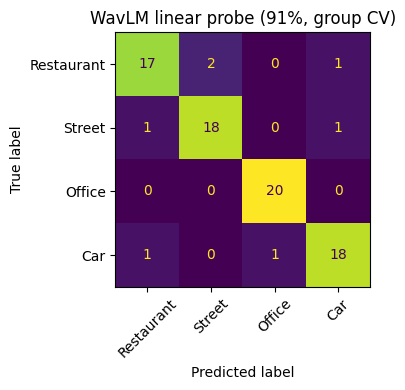

In [7]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

SCENE_NAMES = list(TARGET_SCENES)
groups = data["recording"].values

# Group-aware cross-validation. In each fold, all clips from a recording stay together,
# so the model is always scored on recordings it never trained on (no leakage). With
# cross_val_predict every clip gets predicted exactly once, by a model that didn't see
# its recording -- so we evaluate on all clips instead of one small, noisy test fold.
n_splits = max(2, round(1 / TEST_FRACTION))            # 4 folds, ~25% held out each time
cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))

y_pred = cross_val_predict(clf, X, y, groups=groups, cv=cv)
acc = accuracy_score(y, y_pred)
print(f"Group-aware cross-validated accuracy: {acc:.1%}  ({len(y)} clips, each tested on an unseen recording)\n")
print(classification_report(y, y_pred, labels=SCENE_NAMES, zero_division=0))

# Refit on all data so predict_scene() in the next step uses every clip we have.
clf.fit(X, y)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred, labels=SCENE_NAMES, ax=ax, colorbar=False, xticks_rotation=45
)
ax.set_title(f"WavLM linear probe ({acc:.0%}, group CV)")
plt.tight_layout()
plt.show()

## Step 8 — Predict the scene of one clip

End-to-end inference on a single file: load audio → embed → classify.

In [8]:
def predict_scene(path):
    """Return (predicted_label, {scene: probability})."""
    emb = embed(load_audio(path)).reshape(1, -1)
    pred = clf.predict(emb)[0]
    proba = dict(zip(clf.classes_, clf.predict_proba(emb)[0]))
    return pred, proba


demo_row = data.iloc[0]
pred, proba = predict_scene(demo_row.filepath)

print(f"File       : {demo_row.filepath}")
print(f"True scene : {demo_row.label}")
print(f"Predicted  : {pred}")
print("Confidence :", {k: f"{v:.1%}" for k, v in sorted(proba.items(), key=lambda kv: -kv[1])})

File       : /home/arvinzaheri/.cache/huggingface/hub/datasets--MahiA--TUT2017/snapshots/48f3a8bec2f5f2c9f88461bc5acd1e747484c867/audios/b091_30_40.wav
True scene : Street
Predicted  : Street
Confidence : {'Street': '99.9%', 'Restaurant': '0.1%', 'Car': '0.0%', 'Office': '0.0%'}


## Summary

1. Downloaded labelled acoustic-scene clips from Hugging Face (`MahiA/TUT2017`).
2. Loaded **WavLM** (`microsoft/wavlm-base-plus`) as a frozen feature extractor.
3. Turned each clip into a 768-D embedding via mean-pooling over time.
4. Trained logistic regression on top and predicted scenes on held-out clips.

To try **HuBERT**, set `MODEL_REPO = "facebook/hubert-base-ls960"` and replace `WavLMModel` with `HubertModel` in Step 5.